# Review 1 – Classification Track (Part A)

**Dataset:** `faults_with_missing(1).csv`  
**Task:** Multiclass classification of steel-plate fault type.

### Required workflow
1. Dataset audit
2. Target distribution
3. EDA and visualisations
4. Missing-value, duplicate and outlier checks
5. Feature engineering
6. Stratified 80:20 train/test split
7. Encoding + scaling
8. All 5 Review-1 Part-A classifiers
9. Accuracy, Precision, Recall and weighted F1
10. Confusion matrices
11. Decision-tree visualisation
12. Plot observations at the end


In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42

# Keep the CSV in the same folder as this notebook.
FILE_PATH = "faults_with_missing(1).csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (1941, 34)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42.0000,50.0000,270900.0000,270944.0000,267.0000,17.0000,44.0000,24220.0000,76.0000,108.0000,1687.0000,1.0000,0.0000,80.0000,0.0498,0.2415,0.1818,0.0047,NaN,1.0000,1.0000,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645.0000,651.0000,2538079.0000,2538108.0000,108.0000,10.0000,30.0000,11397.0000,NaN,123.0000,1687.0000,1.0000,0.0000,80.0000,0.7647,0.3793,0.2069,NaN,0.6000,0.9667,1.0000,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829.0000,NaN,1553913.0000,1553931.0000,NaN,8.0000,19.0000,7972.0000,99.0000,125.0000,1623.0000,1.0000,0.0000,100.0000,0.9710,0.3426,0.3333,0.0037,0.7500,0.9474,1.0000,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853.0000,860.0000,369370.0000,369415.0000,176.0000,13.0000,45.0000,18996.0000,99.0000,126.0000,1353.0000,0.0000,1.0000,290.0000,0.7287,0.4413,0.1556,0.0052,0.5385,1.0000,1.0000,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289.0000,1306.0000,498078.0000,498335.0000,NaN,NaN,260.0000,246930.0000,37.0000,NaN,1353.0000,0.0000,1.0000,185.0000,NaN,0.4486,0.0662,0.0126,0.2833,NaN,1.0000,NaN,1.2305,2.4099,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


## 2. Dataset Audit

In [2]:
# =========================
# 2. DATASET AUDIT
# =========================
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
})
display(audit)

print("\nDuplicate rows:", int(df.duplicated().sum()))

TARGET_COLS = [
    "Pastry", "Z_Scratch", "K_Scatch",
    "Stains", "Dirtiness", "Bumps", "Other_Faults"
]

print("\nTarget flag distribution:")
display(df[TARGET_COLS].sum().sort_values(ascending=False).to_frame("count"))

target_sum = df[TARGET_COLS].sum(axis=1)
print("\nNumber of active target flags per row:")
display(target_sum.value_counts().sort_index().to_frame("rows"))


Rows: 1941
Columns: 34

Data types:


,dtype
X_Minimum,float64
X_Maximum,float64
Y_Minimum,float64
Y_Maximum,float64
Pixels_Areas,float64
X_Perimeter,float64
Y_Perimeter,float64
Sum_of_Luminosity,float64
Minimum_of_Luminosity,float64
Maximum_of_Luminosity,float64


,dtype,missing_count,missing_percent,unique_values
X_Minimum,float64,97,5.0000,936
X_Maximum,float64,97,5.0000,962
Y_Minimum,float64,97,5.0000,1842
Y_Maximum,float64,97,5.0000,1843
Pixels_Areas,float64,97,5.0000,892
X_Perimeter,float64,97,5.0000,390
Y_Perimeter,float64,97,5.0000,309
Sum_of_Luminosity,float64,97,5.0000,1815
Minimum_of_Luminosity,float64,97,5.0000,160
Maximum_of_Luminosity,float64,97,5.0000,98



Duplicate rows: 0

Target flag distribution:


,count
Other_Faults,673
Bumps,402
K_Scatch,391
Z_Scratch,190
Pastry,158
Stains,72
Dirtiness,55



Number of active target flags per row:


,rows
1,1941


## 3. Create the Multiclass Target

In [3]:
# =========================
# 3. TARGET CREATION
# =========================
assert (target_sum == 1).all(), "Expected exactly one active fault label per row."

df["Fault_Type"] = df[TARGET_COLS].idxmax(axis=1)

FEATURE_COLS = [c for c in df.columns if c not in TARGET_COLS + ["Fault_Type"]]

print("Feature count:", len(FEATURE_COLS))
print("Target:", "Fault_Type")

class_counts = df["Fault_Type"].value_counts()

print("\nClass distribution:")
display(class_counts.to_frame("count"))

print("\nClass percentages:")
display(
    (df["Fault_Type"].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("percentage")
)


Feature count: 27
Target: Fault_Type

Class distribution:


,count
Fault_Type,
Other_Faults,673
Bumps,402
K_Scatch,391
Z_Scratch,190
Pastry,158
Stains,72
Dirtiness,55



Class percentages:


,percentage
Fault_Type,
Other_Faults,34.6700
Bumps,20.7100
K_Scatch,20.1400
Z_Scratch,9.7900
Pastry,8.1400
Stains,3.7100
Dirtiness,2.8300


## 4. Target Distribution

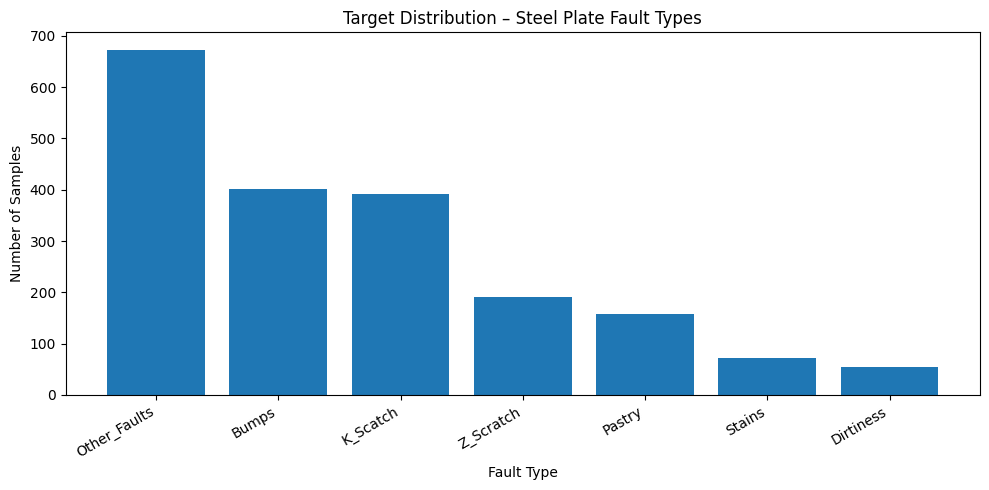

In [4]:
# =========================
# 4. TARGET DISTRIBUTION PLOT
# =========================
plt.figure(figsize=(10, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Target Distribution – Steel Plate Fault Types")
plt.xlabel("Fault Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 5. EDA – Distribution of Every Feature

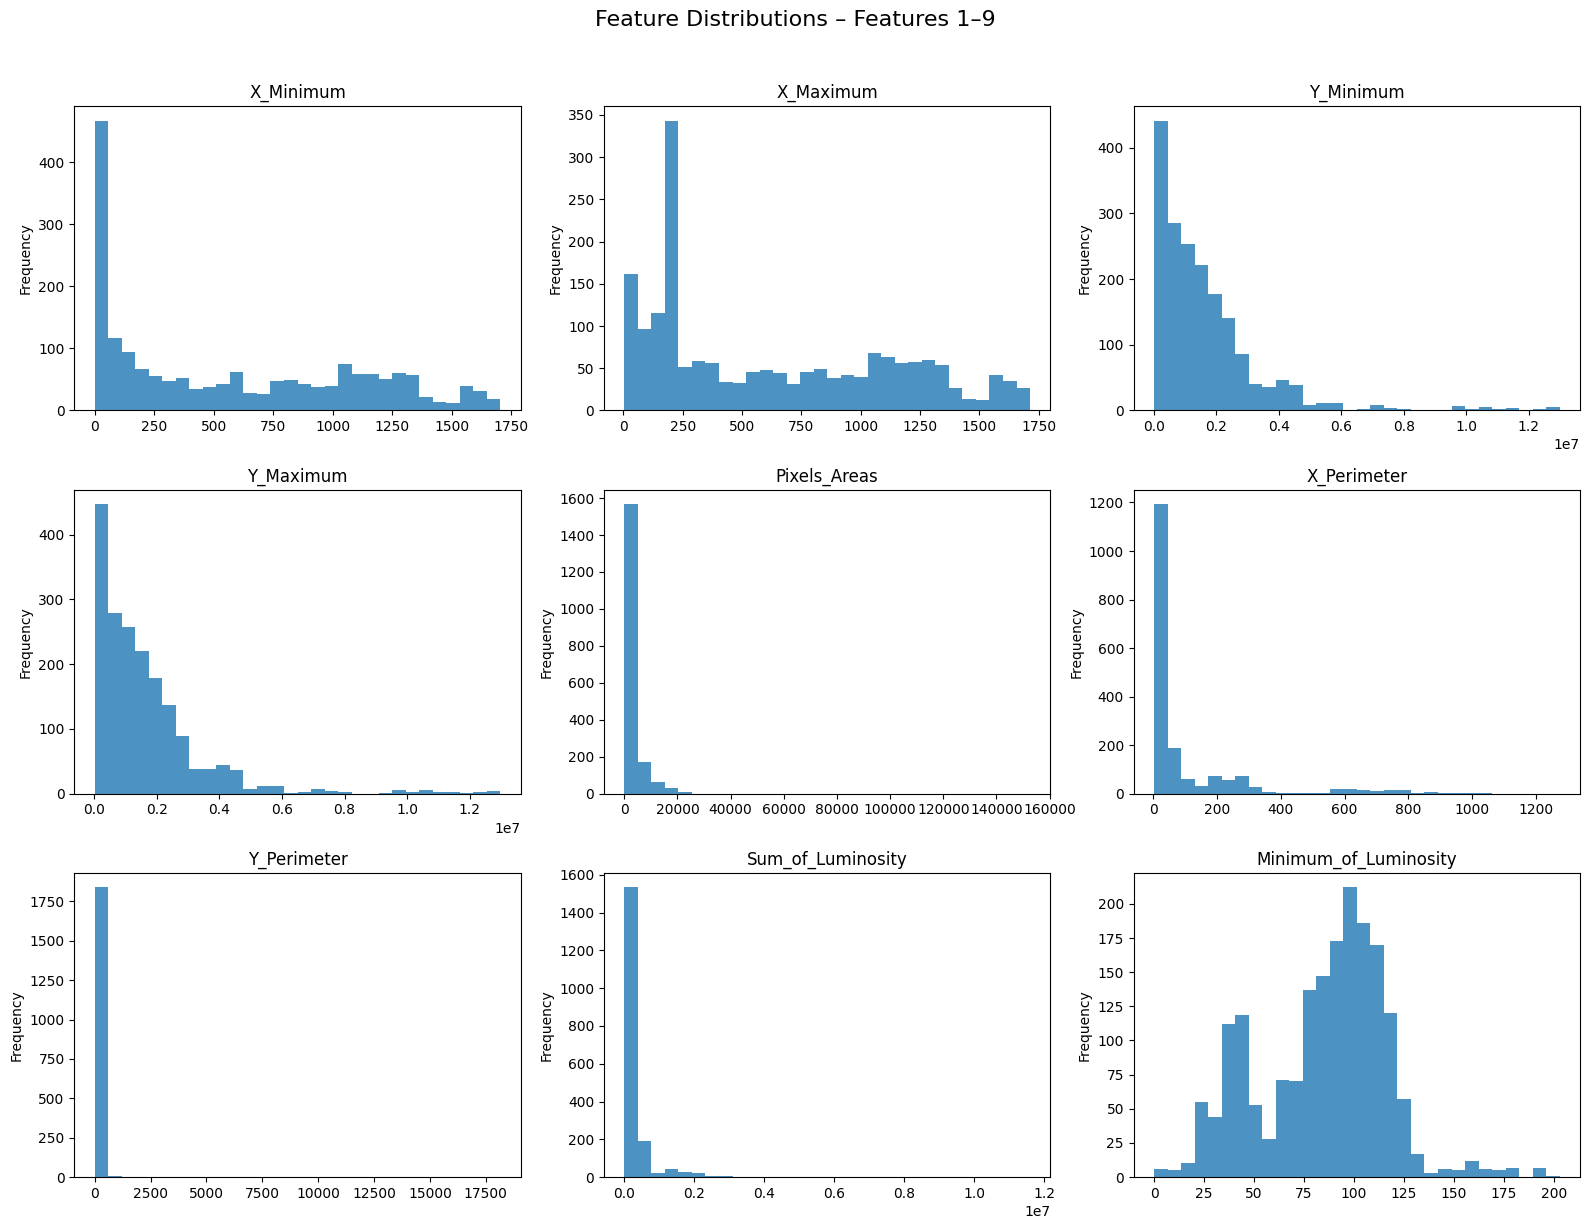

In [5]:
# =========================
# EDA DISTRIBUTIONS: FEATURES 1–9
# =========================
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity']):
    ax.hist(df[col].dropna(), bins=30, alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

for ax in axes[len(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity']):]:
    ax.axis("off")

fig.suptitle("Feature Distributions – Features 1–9", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


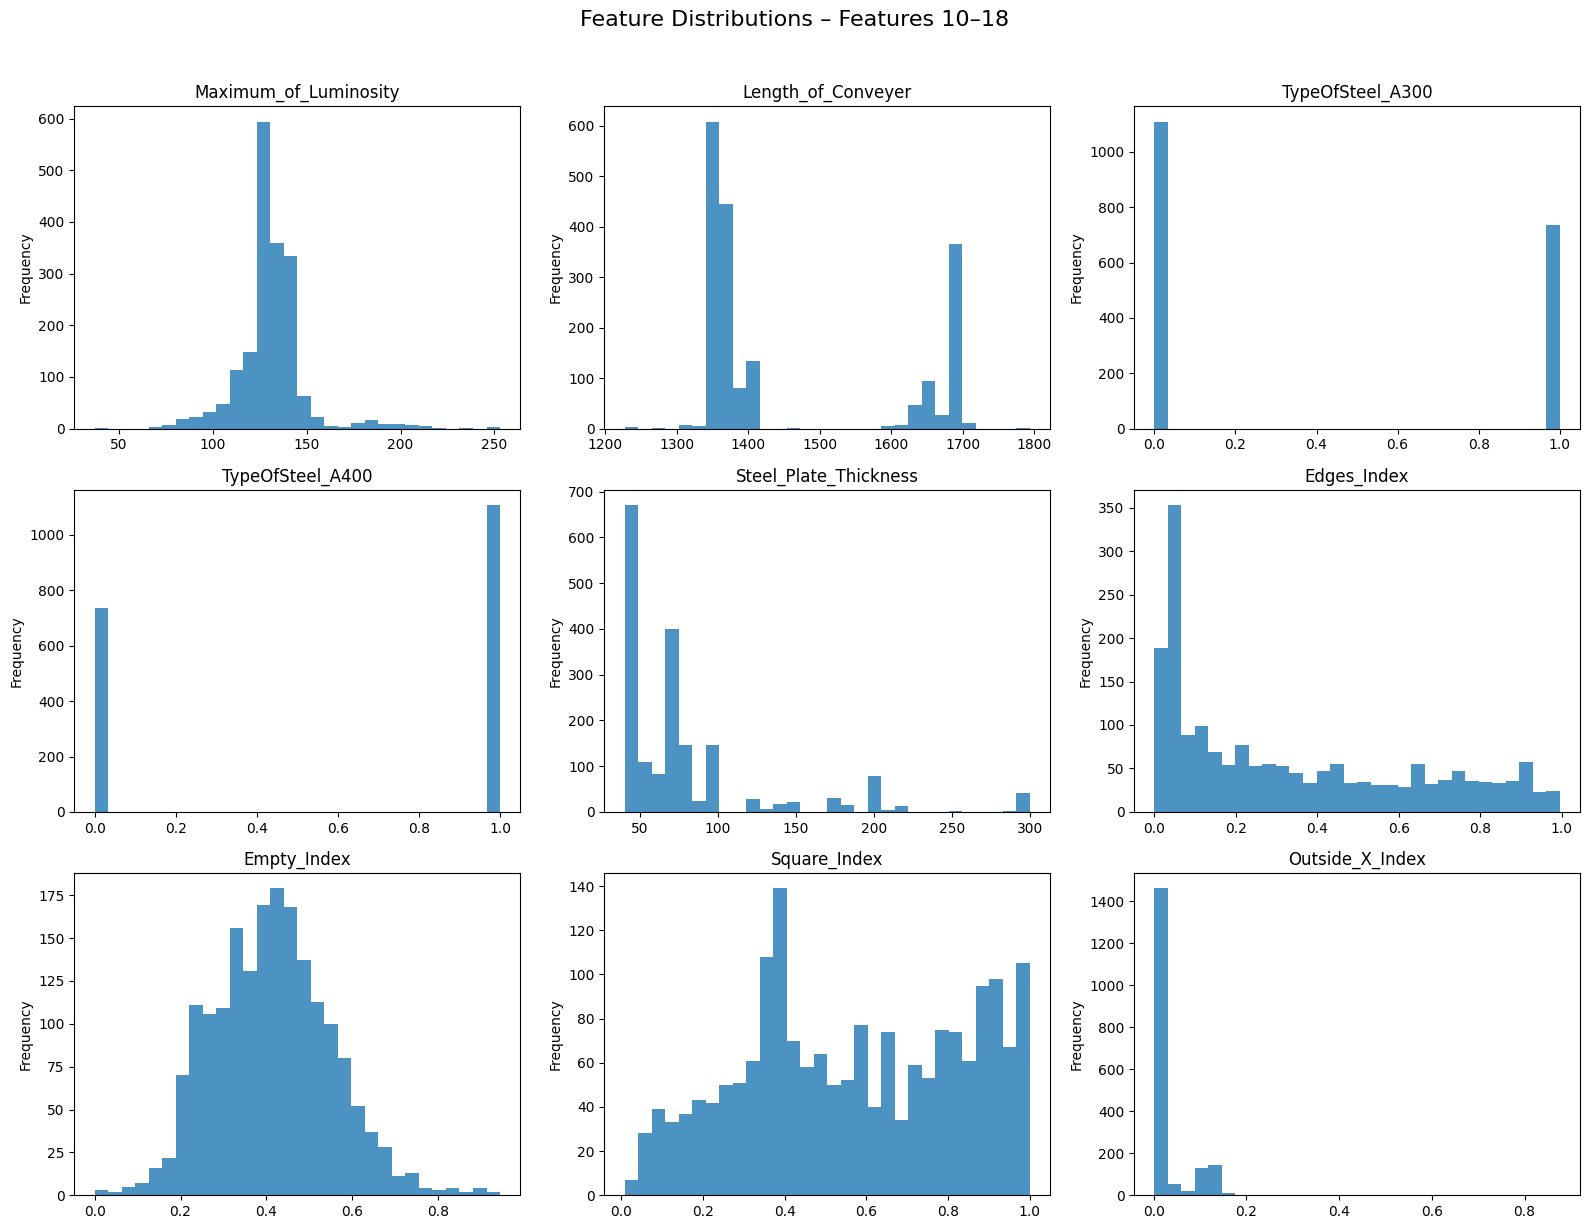

In [6]:
# =========================
# EDA DISTRIBUTIONS: FEATURES 10–18
# =========================
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, ['Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index']):
    ax.hist(df[col].dropna(), bins=30, alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

for ax in axes[len(['Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index']):]:
    ax.axis("off")

fig.suptitle("Feature Distributions – Features 10–18", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


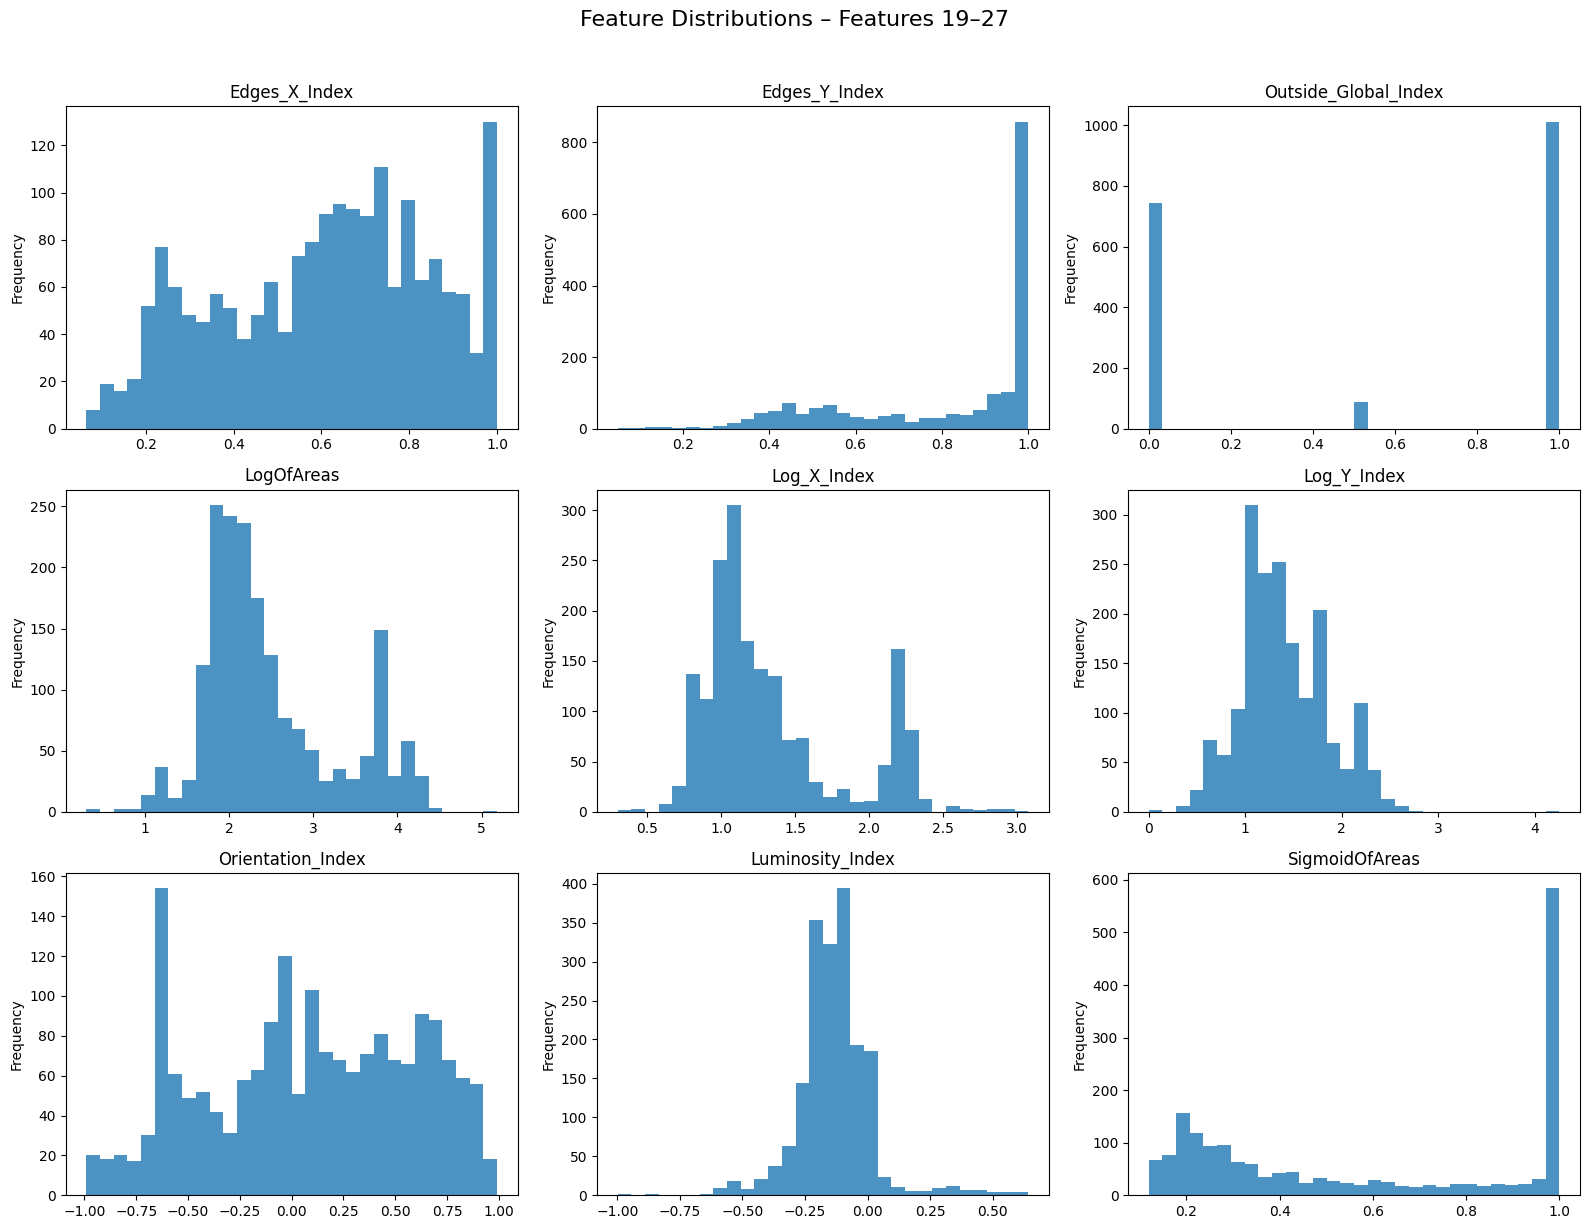

In [7]:
# =========================
# EDA DISTRIBUTIONS: FEATURES 19–27
# =========================
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, ['Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']):
    ax.hist(df[col].dropna(), bins=30, alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

for ax in axes[len(['Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']):]:
    ax.axis("off")

fig.suptitle("Feature Distributions – Features 19–27", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 6. Correlation Heatmap

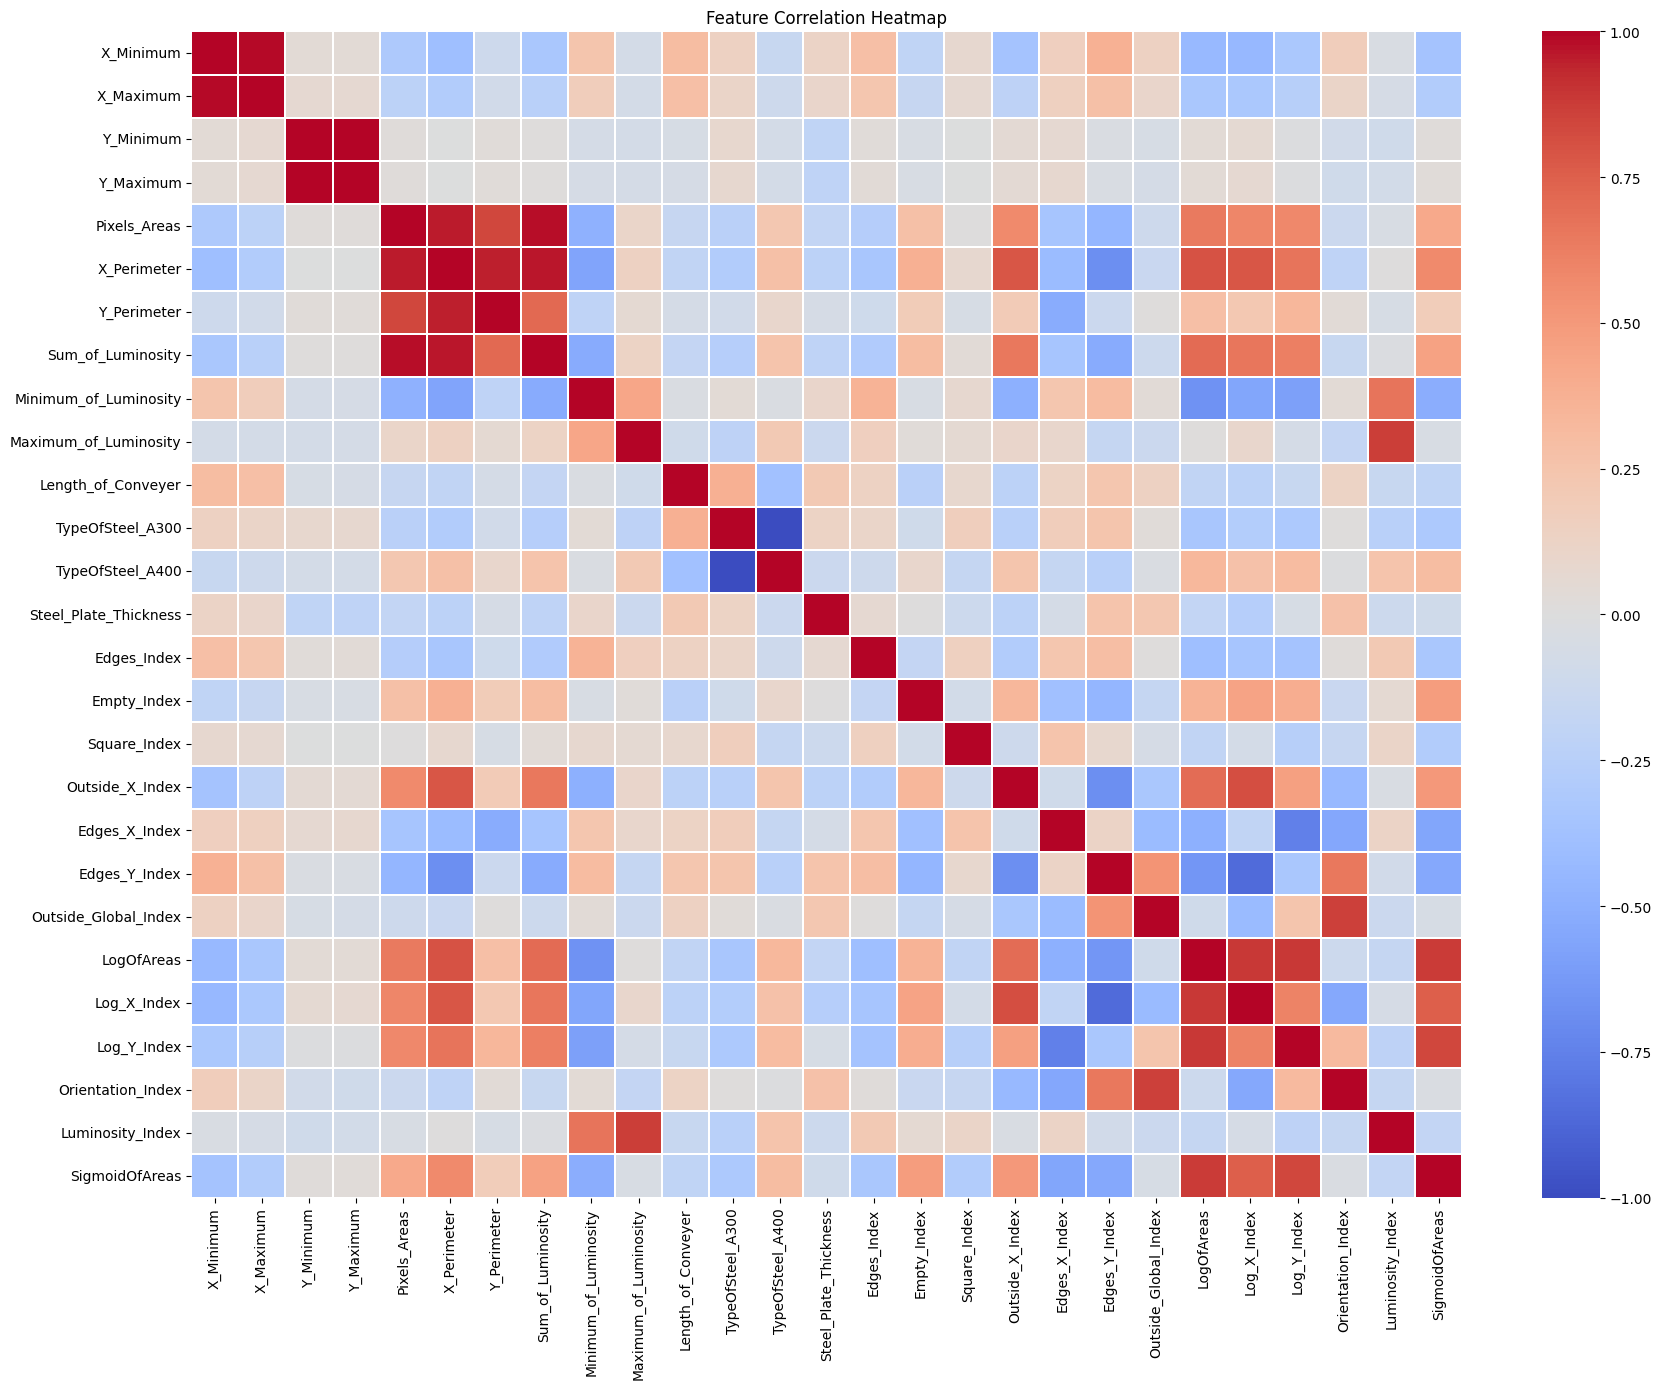

,abs_corr,correlation,feature_1,feature_2
231,1.0000,-1.0000,TypeOfSteel_A300,TypeOfSteel_A400
51,1.0000,1.0000,Y_Minimum,Y_Maximum
0,0.9876,0.9876,X_Minimum,X_Maximum
100,0.9787,0.9787,Pixels_Areas,Sum_of_Luminosity
121,0.9615,0.9615,X_Perimeter,Sum_of_Luminosity
98,0.9591,0.9591,Pixels_Areas,X_Perimeter
120,0.9527,0.9527,X_Perimeter,Y_Perimeter
336,0.8893,0.8893,LogOfAreas,Log_X_Index
337,0.8837,0.8837,LogOfAreas,Log_Y_Index
340,0.8760,0.8760,LogOfAreas,SigmoidOfAreas


In [8]:
corr = df[FEATURE_COLS].corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

corr_pairs = []
for i, c1 in enumerate(FEATURE_COLS):
    for c2 in FEATURE_COLS[i+1:]:
        value = corr.loc[c1, c2]
        if pd.notna(value):
            corr_pairs.append((abs(value), value, c1, c2))

strongest = (
    pd.DataFrame(corr_pairs, columns=["abs_corr", "correlation", "feature_1", "feature_2"])
    .sort_values("abs_corr", ascending=False)
    .head(10)
)
display(strongest)


## 7. Feature–Target Scatter Plots

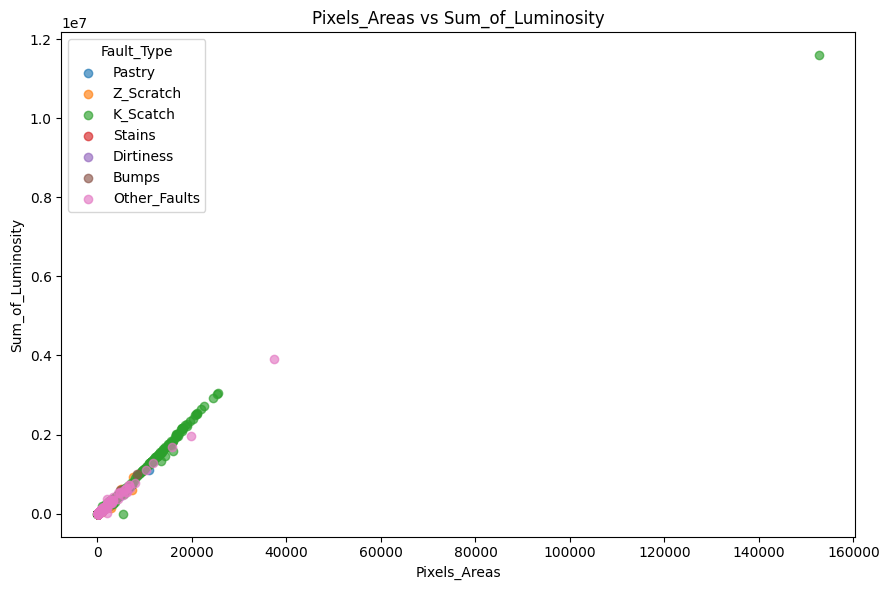

In [9]:
plt.figure(figsize=(9, 6))
for fault in df["Fault_Type"].unique():
    subset = df[df["Fault_Type"] == fault]
    plt.scatter(subset["Pixels_Areas"], subset["Sum_of_Luminosity"], alpha=0.65, label=fault)
plt.title("Pixels_Areas vs Sum_of_Luminosity")
plt.xlabel("Pixels_Areas")
plt.ylabel("Sum_of_Luminosity")
plt.legend(title="Fault_Type")
plt.tight_layout()
plt.show()


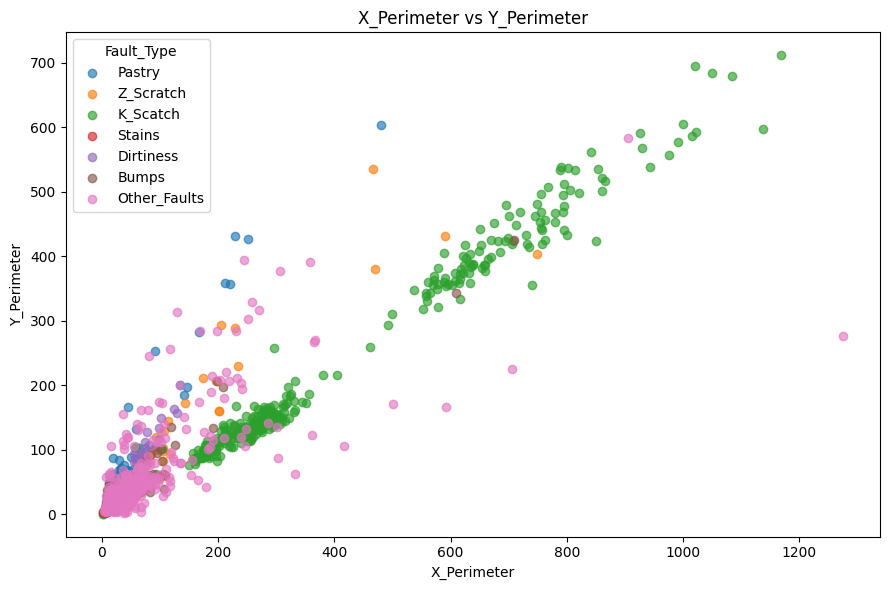

In [10]:
plt.figure(figsize=(9, 6))
for fault in df["Fault_Type"].unique():
    subset = df[df["Fault_Type"] == fault]
    plt.scatter(subset["X_Perimeter"], subset["Y_Perimeter"], alpha=0.65, label=fault)
plt.title("X_Perimeter vs Y_Perimeter")
plt.xlabel("X_Perimeter")
plt.ylabel("Y_Perimeter")
plt.legend(title="Fault_Type")
plt.tight_layout()
plt.show()


## 8. Missing Values, Duplicates and Outliers

In [11]:
missing = df[FEATURE_COLS].isna().sum().sort_values(ascending=False)

print("Total missing feature values:", int(missing.sum()))
print("Rows containing at least one missing feature:",
      int(df[FEATURE_COLS].isna().any(axis=1).sum()))
display(missing[missing > 0].to_frame("missing_count"))

print("Duplicate rows:", int(df.duplicated().sum()))

outlier_summary = []
for col in FEATURE_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    count = ((s < lower) | (s > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["feature", "Q1", "Q3", "lower_fence", "upper_fence", "outlier_count"]
).sort_values("outlier_count", ascending=False)

print("Total IQR-flagged feature values:",
      int(outlier_df["outlier_count"].sum()))
display(outlier_df.head(15))


Total missing feature values: 2619
Rows containing at least one missing feature: 1433


,missing_count
X_Minimum,97
X_Maximum,97
Y_Minimum,97
Y_Maximum,97
Pixels_Areas,97
X_Perimeter,97
Y_Perimeter,97
Sum_of_Luminosity,97
Minimum_of_Luminosity,97
Maximum_of_Luminosity,97


Duplicate rows: 0
Total IQR-flagged feature values: 2327


,feature,Q1,Q3,lower_fence,upper_fence,outlier_count
7,Sum_of_Luminosity,9580.7500,81860.0000,-98838.1250,190278.8750,377
4,Pixels_Areas,85.0000,860.2500,-1077.8750,2023.1250,372
17,Outside_X_Index,0.0066,0.0227,-0.0176,0.0469,350
5,X_Perimeter,15.0000,90.0000,-97.5000,202.5000,320
13,Steel_Plate_Thickness,40.0000,80.0000,-20.0000,140.0000,227
6,Y_Perimeter,13.0000,83.2500,-92.3750,188.6250,170
9,Maximum_of_Luminosity,124.0000,140.0000,100.0000,164.0000,138
25,Luminosity_Index,-0.1950,-0.0664,-0.3879,0.1264,127
3,Y_Maximum,461824.7500,2167777.0000,-2097103.6250,4726705.3750,81
2,Y_Minimum,468209.7500,2182183.5000,-2102750.8750,4753144.1250,80


### Cleaning strategy
- **Missing values:** Median imputation for numeric predictors, fitted only on the training data.
- **Duplicates:** Checked explicitly; duplicate rows are not present.
- **Outliers:** IQR fences are learned from training data and extreme values are capped rather than deleting samples.
- **Categorical predictors:** Predictors are numeric/binary, so ordinary categorical encoding is not needed. The seven fault flags are converted into the multiclass target `Fault_Type`.


## 9. Feature Engineering

In [12]:
X = df[FEATURE_COLS].copy()
y_text = df["Fault_Type"].copy()

def add_engineered_features(data):
    data = data.copy()
    data["Plate_Width"] = data["X_Maximum"] - data["X_Minimum"]
    data["Plate_Height"] = data["Y_Maximum"] - data["Y_Minimum"]
    data["Perimeter_Ratio"] = data["X_Perimeter"] / (data["Y_Perimeter"] + 1e-6)
    data["Area_Perimeter_Ratio"] = (
        data["Pixels_Areas"] /
        (data["X_Perimeter"] + data["Y_Perimeter"] + 1e-6)
    )
    return data

X = add_engineered_features(X)

print("Original feature count:", len(FEATURE_COLS))
print("Feature count after engineering:", X.shape[1])
display(X[[
    "Plate_Width", "Plate_Height",
    "Perimeter_Ratio", "Area_Perimeter_Ratio"
]].head())


Original feature count: 27
Feature count after engineering: 31


,Plate_Width,Plate_Height,Perimeter_Ratio,Area_Perimeter_Ratio
0,8.0000,44.0000,0.3864,4.3770
1,6.0000,29.0000,0.3333,2.7000
2,NaN,18.0000,0.4211,NaN
3,7.0000,45.0000,0.2889,3.0345
4,17.0000,257.0000,NaN,NaN


### Feature-engineering justification
`Plate_Width` and `Plate_Height` capture defect dimensions. `Perimeter_Ratio` captures the relative boundary dimensions, while `Area_Perimeter_Ratio` captures a compact shape characteristic. These engineered relationships may help classifiers distinguish fault types.


## 10. Stratified 80:20 Train/Test Split

In [13]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,
    random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain class proportions (%):")
display(
    pd.Series(label_encoder.inverse_transform(y_train))
    .value_counts(normalize=True).sort_index().mul(100).round(2)
    .to_frame("train_%")
)

print("\nTest class proportions (%):")
display(
    pd.Series(label_encoder.inverse_transform(y_test))
    .value_counts(normalize=True).sort_index().mul(100).round(2)
    .to_frame("test_%")
)


X_train: (1552, 31)
X_test : (389, 31)
y_train: (1552,)
y_test : (389,)

Train class proportions (%):


,train_%
Bumps,20.6800
Dirtiness,2.8400
K_Scatch,20.1700
Other_Faults,34.6600
Pastry,8.1200
Stains,3.7400
Z_Scratch,9.7900



Test class proportions (%):


,test_%
Bumps,20.8200
Dirtiness,2.8300
K_Scatch,20.0500
Other_Faults,34.7000
Pastry,8.2300
Stains,3.6000
Z_Scratch,9.7700


## 11. Encoding, Scaling and Outlier Treatment Pipeline

In [14]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric predictors:", len(numeric_features))
print("Categorical predictors:", len(categorical_features))

class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.q1_ = np.nanpercentile(X, 25, axis=0)
        self.q3_ = np.nanpercentile(X, 75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.factor * self.iqr_
        self.upper_ = self.q3_ + self.factor * self.iqr_
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Preprocessing will be fitted on X_train only.")


Numeric predictors: 31
Categorical predictors: 0
Preprocessing will be fitted on X_train only.


## 12. Review-1 Part-A – All 5 Required Classifiers

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVC": SVC(kernel="rbf", random_state=42)
}

for i, name in enumerate(models, 1):
    print(f"{i}. {name}")


1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree
5. SVC


In [16]:
results = []
fitted_models = {}
predictions = {}
confusion_matrices = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("outlier_treatment", IQRClipper(factor=1.5)),
        ("scaler", StandardScaler()),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    fitted_models[name] = pipeline
    predictions[name] = y_pred
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Weighted F1", ascending=False)
    .reset_index(drop=True)
)

print("All five classifiers trained successfully.")
display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "Weighted F1": "{:.4f}"
}))


All five classifiers trained successfully.


,Model,Accuracy,Precision,Recall,Weighted F1
0,SVC,0.7404,0.7506,0.7404,0.7407
1,K-Nearest Neighbors,0.7352,0.7448,0.7352,0.7314
2,Decision Tree,0.6915,0.6995,0.6915,0.6933
3,Logistic Regression,0.6761,0.6828,0.6761,0.6777
4,Gaussian Naive Bayes,0.5913,0.6499,0.5913,0.5706


## 13. Classification Reports

In [17]:
class_names = label_encoder.classes_

for name in models:
    print("=" * 80)
    print(name)
    print("=" * 80)
    print(classification_report(
        y_test, predictions[name],
        target_names=class_names,
        zero_division=0
    ))


Logistic Regression
              precision    recall  f1-score   support

       Bumps       0.61      0.52      0.56        81
   Dirtiness       0.64      0.64      0.64        11
    K_Scatch       0.92      0.87      0.89        78
Other_Faults       0.58      0.65      0.62       135
      Pastry       0.51      0.56      0.54        32
      Stains       0.79      0.79      0.79        14
   Z_Scratch       0.83      0.76      0.79        38

    accuracy                           0.68       389
   macro avg       0.70      0.68      0.69       389
weighted avg       0.68      0.68      0.68       389

K-Nearest Neighbors
              precision    recall  f1-score   support

       Bumps       0.56      0.73      0.63        81
   Dirtiness       0.90      0.82      0.86        11
    K_Scatch       0.97      0.96      0.97        78
Other_Faults       0.69      0.64      0.67       135
      Pastry       0.73      0.34      0.47        32
      Stains       0.71      0.71     

## 14. Confusion Matrices

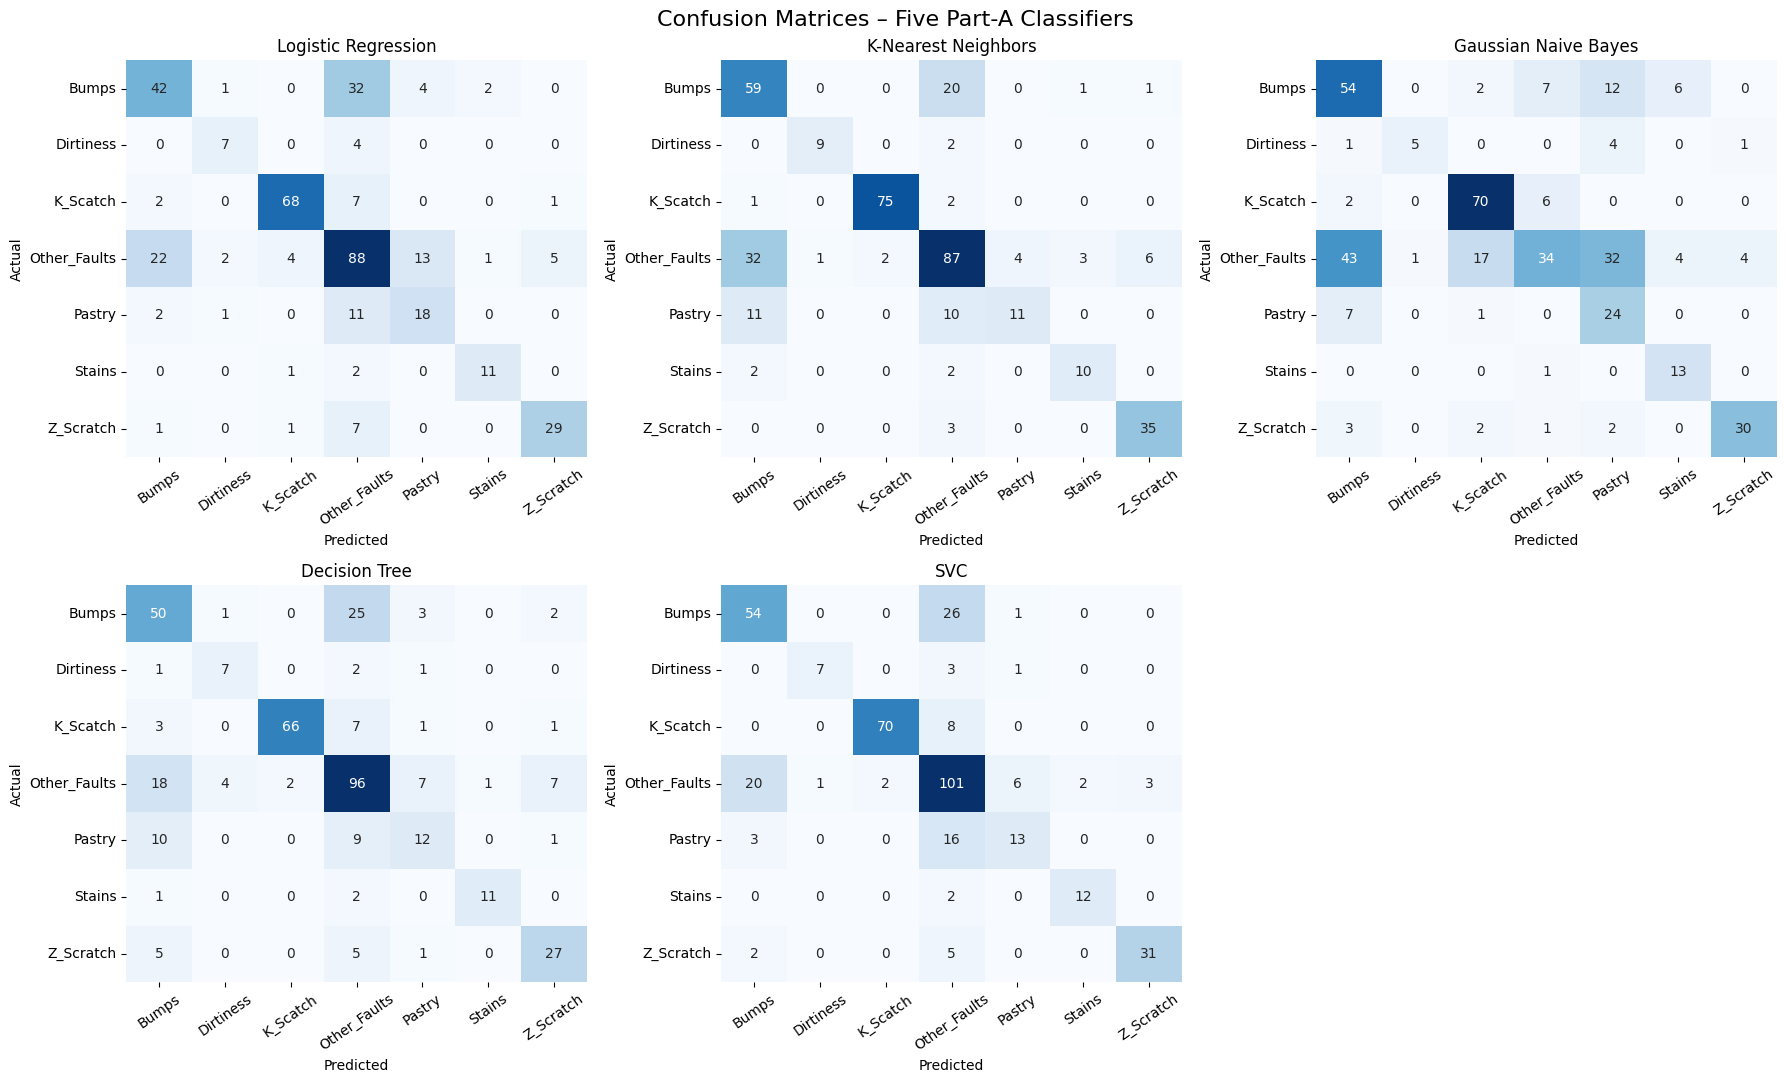

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

axes[-1].axis("off")
fig.suptitle("Confusion Matrices – Five Part-A Classifiers", fontsize=16)
plt.tight_layout()
plt.show()


## 15. Decision-Tree Visualisation

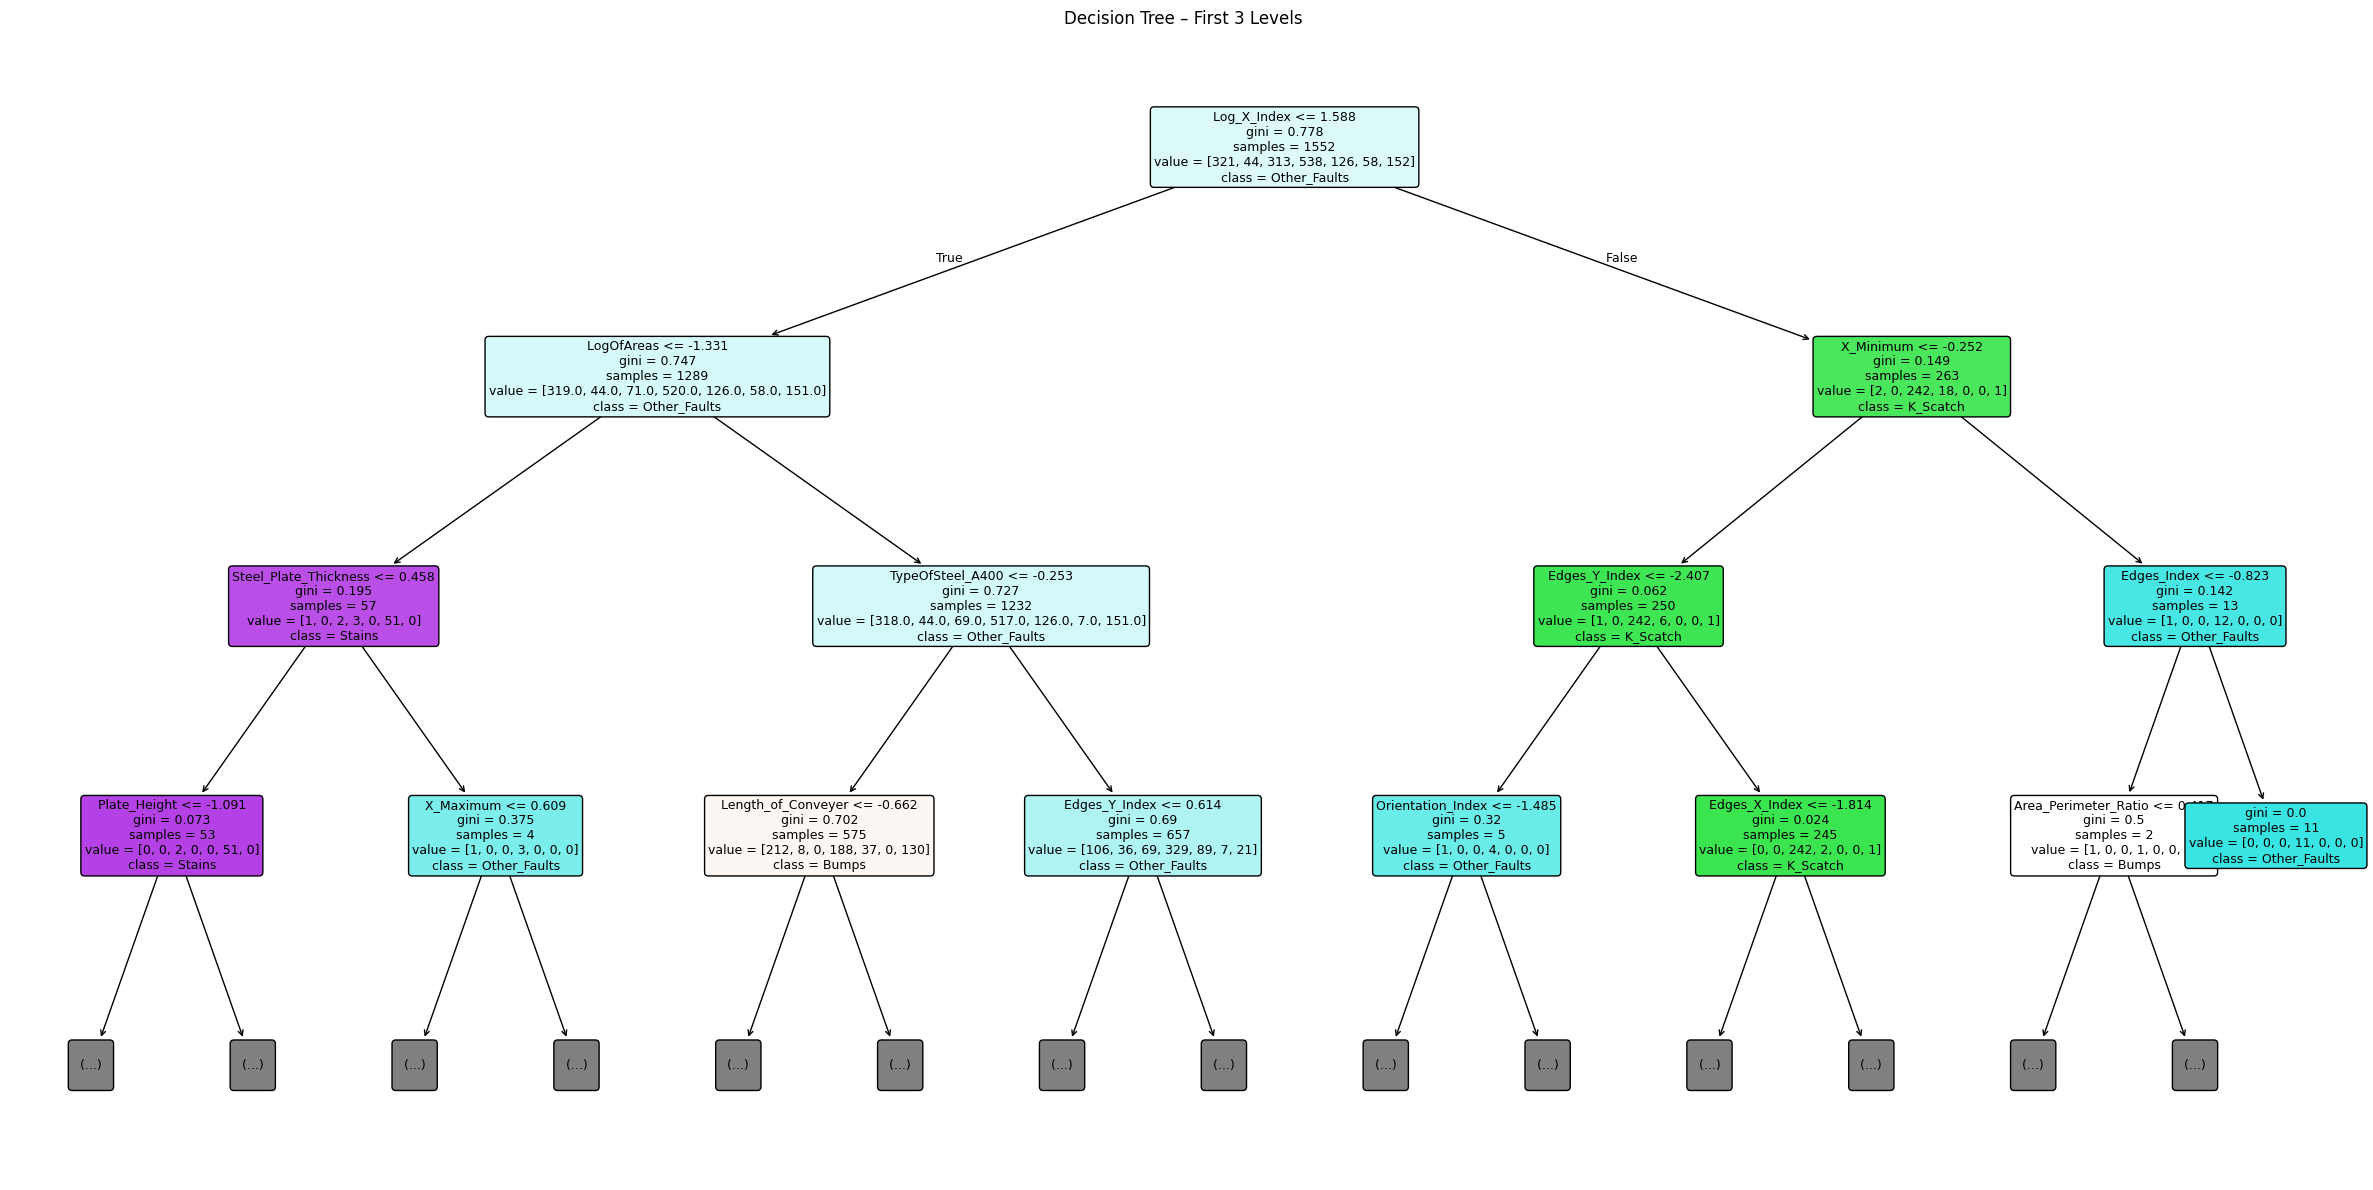

Top decision-tree features:


,Feature,Importance
22,Log_X_Index,0.1772
10,Length_of_Conveyer,0.0934
13,Steel_Plate_Thickness,0.0651
2,Y_Minimum,0.0574
21,LogOfAreas,0.0491
19,Edges_Y_Index,0.0480
0,X_Minimum,0.0475
14,Edges_Index,0.0429
16,Square_Index,0.0355
12,TypeOfSteel_A400,0.0327


In [19]:
tree_pipeline = fitted_models["Decision Tree"]
tree_model = tree_pipeline.named_steps["classifier"]
feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree – First 3 Levels")
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top decision-tree features:")
display(importance_df.head(15))
